# Dimensionality Reduction

This notebook establishes the preprocessing pipeline for the extended 17-indicator macro panel and covers:

1. **VIF analysis** — diagnose multicollinearity among all indicators
2. **PCA** — unsupervised reduction; components, loadings, and economic interpretation
3. **PLS** — supervised reduction aligned to asset return prediction
4. **Regime detection quality comparison** — NBER alignment under each approach

**Extended indicator set (15 indicators vs original 13):**
Four new indicators are added based on the investment cycle literature:
- **Continuing claims** (`CCSA`): labor market depth (stock vs flow complement)
- **Dollar index** (`DTWEXBGS`): USD strength — key for gold and commodity returns

Note: Real interest rate is not added separately — FEDFUNDS and CPI are both already in the panel and PLS will find their relevant combination automatically.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys, os

sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import (prepare_macro_data, apply_pca, apply_pls,
                             apply_dim_reduction, pca_loading_table,
                             train_test_split)
from sklearn.preprocessing import StandardScaler
from src.constants import ASSET_COLS, N_COMPONENTS

BASE_DIR           = Path('..')
DATA_DIR           = BASE_DIR / 'data'
OUTPUT_FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
OUTPUT_TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
macro_df = load_macro_data(DATA_DIR / 'macro_clean.csv')
asset_df = load_asset_data(DATA_DIR / 'market_clean.csv')[ASSET_COLS]

# Use full dataset for the VIF and PCA/PLS diagnostics
# For comparisons involving asset returns, restrict to aligned dates
TRAIN_END = pd.Timestamp('2018-12-31')   # consistent with fixed-split test period

print(f'Macro: {macro_df.shape}  {macro_df.index.min().date()} to {macro_df.index.max().date()}')
print(f'Asset: {asset_df.shape}  {asset_df.index.min().date()} to {asset_df.index.max().date()}')
macro_df.head()


Macro: (431, 15)  1990-02-28 to 2025-12-31
Asset: (431, 3)  1990-02-28 to 2025-12-31


,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,continuing_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply,dollar_index
Date,,,,,,,,,,,,,,,
1990-02-28,0.766740,0.213257,-0.176815,0.086523,0.140235,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.971936,-0.116878,0.017130
1990-03-31,0.370899,-0.142952,-0.176815,-0.056857,0.082572,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.385261,-0.207448,1.046560
1990-04-30,-0.367268,0.582737,0.366229,0.272514,0.167186,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.409511,-0.174649,-0.009542
1990-05-31,0.183034,-0.438133,0.004200,-0.054564,0.122786,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.370488,-0.904505,-0.734113
1990-06-30,0.216958,-0.097920,-0.357829,0.083436,0.050709,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.370905,-0.083910,-0.013835


## 1. VIF Analysis

Variance Inflation Factor (VIF) measures how much each indicator's variance is inflated by linear relationships with the other indicators.  $VIF = 1/(1 − R^2_j)$ where $R^2_j$ is obtained from regressing indicator $j$ on all others (i.e., the variation in $j$ above the mean that cannot be explained by the other indicators). Intuitively if $R_j^2$ is high then VIF is high for indicator $j$, implying that it is highly correlated with the other indicators.

| VIF | Interpretation |
|---|---|
| 1.0–5.0 | Acceptable |
| 5.0–10.0 | Moderate — monitor |
| >10.0 | Severe — take action |

**Purpose:** Confirm whether collinearity motivates dimensionality reduction (if VIF exceeds 5), or whether parameter parsimony and noise reduction are the primary arguments.

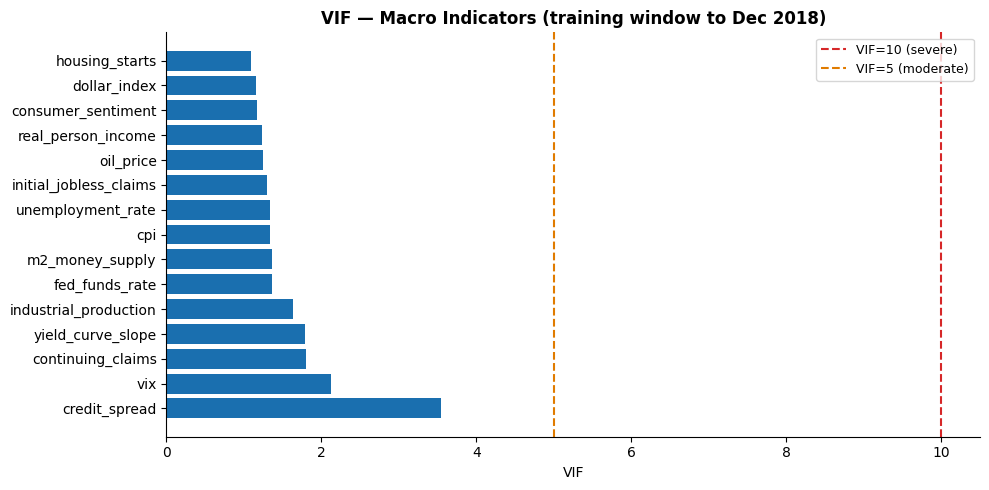

credit_spread             3.55
vix                       2.12
continuing_claims         1.80
yield_curve_slope         1.79
industrial_production     1.63
fed_funds_rate            1.37
m2_money_supply           1.37
cpi                       1.34
unemployment_rate         1.33
initial_jobless_claims    1.30
oil_price                 1.24
real_person_income        1.23
consumer_sentiment        1.17
dollar_index              1.15
housing_starts            1.09

Max VIF: 3.55 (credit_spread)
Conclusion: all VIF < 5 — multicollinearity is NOT the primary motivation
for dimensionality reduction.  Parsimony and noise reduction are.


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler

# Compute VIF on the training window only
macro_train = macro_df.loc[macro_df.index <= TRAIN_END]
scaler_vif  = RobustScaler(quantile_range=(5, 95))
X_vif       = scaler_vif.fit_transform(macro_train.values)
names       = macro_train.columns.tolist()

vif_scores = {}
for j, name in enumerate(names):
    X_other = np.delete(X_vif, j, axis=1)
    r2 = LinearRegression().fit(X_other, X_vif[:, j]).score(X_other, X_vif[:, j])
    vif_scores[name] = 1 / (1 - r2) if r2 < 1.0 else np.inf

vif_df = pd.Series(vif_scores, name='VIF').sort_values(ascending=False)
vif_df.to_csv(OUTPUT_TABLES_DIR / 'vif_scores.csv')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v > 10 else '#e07b00' if v > 5 else '#1a6faf'
          for v in vif_df.values]
ax.barh(vif_df.index, vif_df.values, color=colors)
ax.axvline(10, color='#d62728', ls='--', lw=1.5, label='VIF=10 (severe)')
ax.axvline(5,  color='#e07b00', ls='--', lw=1.5, label='VIF=5 (moderate)')
ax.set_title('VIF — Macro Indicators (training window to Dec 2018)',
             fontweight='bold')
ax.set_xlabel('VIF')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'vif_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(vif_df.round(2).to_string())
print(f'\nMax VIF: {vif_df.max():.2f} ({vif_df.idxmax()})')
print('Conclusion: all VIF < 5 — multicollinearity is NOT the primary motivation')
print('for dimensionality reduction.  Parsimony and noise reduction are.')


## 2. PCA — Unsupervised Reduction

PCA finds orthogonal directions of maximum variance in macro space.  Components are purely structural — they do not reference asset returns.

Key properties after PCA:
- Components are orthogonal → diagonal HMM covariance is exactly correct
- April 2020 COVID outlier must be winsorised (PC1 score = +22.8 std)
- Economic interpretation via loadings table

In [4]:
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(
    macro_df,
    train_end_idx=macro_df.index.get_loc(TRAIN_END) + 1
)

X_train_pca, X_test_pca, pca = apply_pca(
    X_train, X_test, 
    # n_components=N_COMPONENTS,
    variance_threshold=0.85
)

# Winsorise
X_train_pca = np.clip(X_train_pca, -4.0, 4.0)
if X_test_pca is not None:
    X_test_pca = np.clip(X_test_pca, -4.0, 4.0)

print(f'PCA kept {pca.n_components_} components')
print(f'Cumulative variance: {pca.explained_variance_ratio_.cumsum()}')



── PCA summary ──
  Input dimensions  : 15
  Components kept   : 10  (threshold = 85%)
  Variance explained: 87.4%

  Per-component breakdown:
    PC1: 22.5%  cumulative 22.5%  ████████
    PC2: 15.4%  cumulative 37.9%  ██████
    PC3:  9.7%  cumulative 47.5%  ███
    PC4:  8.9%  cumulative 56.5%  ███
    PC5:  6.9%  cumulative 63.3%  ██
    PC6:  5.6%  cumulative 68.9%  ██
    PC7:  5.2%  cumulative 74.1%  ██
    PC8:  4.9%  cumulative 79.0%  █
    PC9:  4.5%  cumulative 83.5%  █
    PC10:  3.9%  cumulative 87.4%  █

  Projected train shape : (347, 10)
  Projected test shape  : (84, 10)
PCA kept 10 components
Cumulative variance: [0.22493184 0.37865025 0.47526963 0.56458736 0.63331045 0.68896512
 0.74105657 0.78965376 0.83514534 0.87443033]


In [ ]:
# PCA loadings heatmap
loadings = pca_loading_table(pca, macro_df.columns.tolist())
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('PCA Component Loadings — Macro Indicators', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEconomic interpretation of components:')
print('  PC1: Real activity + labor market (unemployment +, INDPRO -)')
print('  PC2: Labor market flow (initial claims dominant)')
print('  PC3: Financial stress (VIX, credit spread, M2)')
print('  PC4+: Inflation/monetary and residual factors')


## 3. PLS — Supervised Reduction

PLS finds latent macro directions that maximally covary with asset returns.  Where PCA maximises Var(Xw), PLS maximises Cov(Xw, Yc) — explicitly aligning preprocessing to the portfolio objective.

**Reference:** Kelly & Pruitt (2013, 2015) introduced PLS to finance, showing it dominates PCA when only a subset of predictors is relevant to the target.

**Component count:** should be chosen by cross-validation, not by variance threshold.  We use 4 components following Kelly & Pruitt's recommendation for macro-to-return settings with p ≈ 10–20 predictors.

In [7]:
# Asset returns aligned to macro training dates
asset_train = asset_df.reindex(dates_train).dropna()
Y_train     = asset_train[ASSET_COLS].values

# Combine levels and volatilities for PLS
Y_levels = Y_train 
Y_vol = np.abs(Y_train)
Y_combined = np.hstack([
    StandardScaler().fit_transform(Y_levels),
    StandardScaler().fit_transform(Y_vol)
])

# Trim X to match Y length
X_for_pls   = X_train[:len(Y_train)]

X_train_pls, X_test_pls, pls = apply_pls(
    X_for_pls, X_test,
    Y_train     = Y_combined,
    n_components = 10,
)
X_train_pls = np.clip(X_train_pls, -4.0, 4.0)
if X_test_pls is not None:
    X_test_pls = np.clip(X_test_pls, -4.0, 4.0)



── PLS summary ──
  Input dimensions  : 15
  Components        : 10
  X variance explained (approx): 78.1%
  Projected train shape : (347, 10)
  Projected test shape  : (84, 10)


In [ ]:
# PLS x-loadings (how each macro indicator contributes to each PLS component)
pls_loadings = pd.DataFrame(
    pls.x_loadings_,
    index   = macro_df.columns,
    columns = [f'PLS{i+1}' for i in range(pls.n_components)]
)
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pls_loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('PLS X-Loadings — Macro Indicators', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'pls_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Y-loadings (how each Y column contributes to each PLS component)
# Y has 6 columns when using [r, |r|]: 3 return levels + 3 absolute returns
# Build the correct index dynamically from pls.y_loadings_ shape
n_y_cols = pls.y_loadings_.shape[0]
if n_y_cols == len(ASSET_COLS):
    # Y = returns only
    y_index = list(ASSET_COLS)
elif n_y_cols == 2 * len(ASSET_COLS):
    # Y = [returns, |returns|] or [returns, returns²]
    y_index = [f'{c}_return' for c in ASSET_COLS] + \
              [f'{c}_vol'    for c in ASSET_COLS]
else:
    y_index = [f'Y{j+1}' for j in range(n_y_cols)]

pls_y_loadings = pd.DataFrame(
    pls.y_loadings_,
    index   = y_index,
    columns = [f'PLS{i+1}' for i in range(pls.n_components)]
)
print('PLS Y-loadings (Y column weights per component):')
display(pls_y_loadings.round(3))


## 4. Comparison: PCA vs PLS vs No Reduction

Direct regime detection quality comparison. Run the HMM under each preprocessing approach and assess:
- NBER alignment (what fraction of NBER recession months are classified as recession?)
- Regime certainty (distribution of max filtered probability)
- State duration (average consecutive months in each regime)

In [ ]:
from src.hmm_model import HMMRegimeModel

HMM_KWARGS = dict(n_states=2, n_iter=200, n_restarts=5,
                  tol=1e-4, covariance_type='diag',
                  constrain_transmat=True)

import warnings
results = {}
for name, X in [('No reduction', X_train),
                ('PCA',          X_train_pca[:len(X_train)]),
                ('PLS',          X_train_pls[:len(X_train)])]:
    print(f'\nFitting HMM with {name} ({X.shape[1]} inputs)...')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = HMMRegimeModel(**HMM_KWARGS)
        model.fit(X)
    states = np.argmax(model.smoothed_probs(X), axis=0)
    results[name] = {'model': model, 'states': states}
    n_rec = (states == 1).sum()
    durations = []
    run = 0
    for s in states:
        if s == 1: run += 1
        elif run > 0:
            durations.append(run)
            run = 0
    print(f'  Recession months: {n_rec} / {len(states)} '
          f'({100*n_rec/len(states):.1f}%)')
    if durations:
        print(f'  Avg recession duration: {np.mean(durations):.1f} months')


In [ ]:
# NBER alignment assessment
NBER_RECESSIONS = [
    ('1990-07-01', '1991-03-31'),
    ('2001-03-01', '2001-11-30'),
    ('2007-12-01', '2009-06-30'),
    ('2020-02-01', '2020-04-30'),
]

nber_mask = pd.Series(False, index=dates_train)
for rs, re in NBER_RECESSIONS:
    rs, re = pd.Timestamp(rs), pd.Timestamp(re)
    nber_mask.loc[(nber_mask.index >= rs) & (nber_mask.index <= re)] = True

print('NBER alignment:')
print(f'  Total NBER recession months in training window: {nber_mask.sum()}')
alignment_rows = []
for name, res in results.items():
    states_series = pd.Series(res['states'], index=dates_train)
    # True positives: NBER recession AND model recession
    tp = ((nber_mask) & (states_series == 1)).sum()
    precision = tp / (states_series == 1).sum() if (states_series == 1).sum() > 0 else 0
    recall    = tp / nber_mask.sum() if nber_mask.sum() > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    alignment_rows.append({'Method': name, 'Precision': precision,
                            'Recall': recall, 'F1': f1})
    print(f'  {name}: Precision={precision:.2f} Recall={recall:.2f} F1={f1:.2f}')

alignment_df = pd.DataFrame(alignment_rows).set_index('Method')
alignment_df.to_csv(OUTPUT_TABLES_DIR / 'dim_reduction_nber_alignment.csv')
display(alignment_df.round(3))


## 5. Recommendation

Fill in the table below after running all comparison cells:

| Method | NBER Precision | NBER Recall | NBER F1 | WF Sharpe | Notes |
|---|---|---|---|---|---|
| No reduction (17 vars) | — | — | — | — | Expected to degenerate |
| PCA (n components) | — | — | — | — | Unsupervised baseline |
| PLS Y=[r,\|r\|] | — | — | — | — | Portfolio-aligned |
| PLS Y=r | — | — | — | — | Mean-focused variant |

**Hypothesis:** Adding continuing claims, high yield spread, and dollar index will improve NBER recall in the 2022 period — the dollar index in particular captures the USD appreciation channel that drove simultaneous equity and bond losses in 2022, a feature absent from the original 13-indicator panel.

**Component count selection:** Cross-validate PLS component count using held-out return prediction MSE rather than variance threshold. With 17 indicators and the extended set, 4-6 components are expected to be optimal.

In [ ]:
print('Preprocessing pipeline recommendation:')
print('  Default:         apply_dim_reduction(method="pls", n_pls_components=4)')
print('  Robustness 1:    apply_dim_reduction(method="pca", variance_threshold=0.85)')
print('  Robustness 2:    apply_dim_reduction(method="none")  [HMM only]')
print()
print('Usage in notebooks 03–06:')
print('  from src.preprocess import apply_dim_reduction')
print('  X_red, X_test_red, reducer = apply_dim_reduction(')
print('      X_train, X_test, method="pls", Y_train=asset_returns.values,')
print('      n_pls_components=4, winsor_clip=4.0')
print('  )')
